In [ ]:
#stage 2 embedding


In [ ]:
import sys
import os
import shutil
import subprocess
from pathlib import Path

print("=== Python ===")
print("sys.executable:", sys.executable)
print("Python version:", sys.version)

print("\n=== Current directory ===")
print(Path.cwd())

print("\n=== Environment variables ===")
print("VIRTUAL_ENV:", os.environ.get("VIRTUAL_ENV"))
print("UV_PROJECT_ENVIRONMENT:", os.environ.get("UV_PROJECT_ENVIRONMENT"))
print("CONDA_PREFIX:", os.environ.get("CONDA_PREFIX"))

print("\n=== Commands found ===")
for cmd in ["python", "pip", "uv", "jupyter"]:
    print(f"{cmd}: {shutil.which(cmd)}")

print("\n=== Package locations ===")
for package in ["ipywidgets", "ipykernel", "jupyter", "tqdm"]:
    try:
        result = subprocess.run(
            [sys.executable, "-m", "pip", "show", package],
            capture_output=True,
            text=True,
            check=False,
        )
        location = None
        version = None

        for line in result.stdout.splitlines():
            if line.startswith("Version:"):
                version = line.split(":", 1)[1].strip()
            elif line.startswith("Location:"):
                location = line.split(":", 1)[1].strip()

        print(f"{package}: version={version}, location={location}")
    except Exception as e:
        print(f"{package}: error: {e}")

In [ ]:
import sys
import subprocess

print("=== uv version ===")
subprocess.run(["uv", "--version"], check=False)

print("\n=== Installed kernels ===")
subprocess.run(
    [sys.executable, "-m", "jupyter", "kernelspec", "list"],
    check=False,
)

In [ ]:
import ipywidgets
import sys

print("Python:", sys.executable)
print("ipywidgets:", ipywidgets.__version__)

In [ ]:
from pathlib import Path
import os
from pathlib import Path
import os
import pandas as pd

os.environ["WANDB_DISABLED"] = "true"

PROJECT_DIR = Path.cwd()

print("Current working directory:")
print(PROJECT_DIR)

assert (PROJECT_DIR / "tokenized_data").exists(), (
    "Wrong working directory. Expected the Geneformer KD project folder."
)

# Stage 1 tokenized dataset
STAGE1_TOKENIZED_DATASET = (
    PROJECT_DIR
    / "tokenized_data"
    / "01_primary_celltype"
    / "01_primary_celltype.dataset"
)

# Stage 2 tokenized dataset
STAGE2_TOKENIZED_DATASET = (
    PROJECT_DIR
    / "tokenized_data"
    / "02_disease"
    / "02_disease.dataset"
)

# Model run folders
STAGE1_RUN_DIR = (
    PROJECT_DIR
    / "runs_geneformer_v2"
    / "01_primary_celltype"
)

STAGE2_RUN_DIR = (
    PROJECT_DIR
    / "runs_geneformer_v2"
    / "02_disease"
)

# Output folders
EMBED_DIR = PROJECT_DIR / "embedding_analysis"

STAGE1_EMBED_DIR = EMBED_DIR / "stage1_celltype_model"
STAGE2_EMBED_DIR = EMBED_DIR / "stage2_disease_model"

for folder in [
    EMBED_DIR,
    STAGE1_EMBED_DIR,
    STAGE2_EMBED_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("\nStage 1 tokenized dataset:")
print(STAGE1_TOKENIZED_DATASET)

print("\nStage 2 tokenized dataset:")
print(STAGE2_TOKENIZED_DATASET)

print("\nExistence checks:")
print("Stage 1 dataset:", STAGE1_TOKENIZED_DATASET.exists())
print("Stage 2 dataset:", STAGE2_TOKENIZED_DATASET.exists())
print("Stage 1 run dir:", STAGE1_RUN_DIR.exists())
print("Stage 2 run dir:", STAGE2_RUN_DIR.exists())
# ==========================
# Master evaluation table
# ==========================

MASTER_TABLE = EMBED_DIR / "embedding_master_table.csv"

print("\nMaster table:")
print(MASTER_TABLE)

if MASTER_TABLE.exists():

    master_df = pd.read_csv(MASTER_TABLE)

    print("\nCurrent model summary:")
    display(master_df)

    print("\nModels already evaluated:")
    for model in master_df["Model"]:
        print(f"  ✓ {model}")

else:

    print("\nNo master table found.")
    print("A new one will be created after this stage.")

In [ ]:
#inspect class mapping
import pickle

STAGE1_ID_CLASS_FILE = (
    STAGE1_RUN_DIR / "01_primary_celltype_id_class_dict.pkl"
)

STAGE2_ID_CLASS_FILE = (
    STAGE2_RUN_DIR / "02_disease_id_class_dict.pkl"
)

with open(STAGE1_ID_CLASS_FILE, "rb") as f:
    stage1_id_class_dict = pickle.load(f)

with open(STAGE2_ID_CLASS_FILE, "rb") as f:
    stage2_id_class_dict = pickle.load(f)

print("Stage 1 class mapping:")
print(stage1_id_class_dict)

print("\nStage 2 class mapping:")
print(stage2_id_class_dict)

N_STAGE1_CLASSES = len(stage1_id_class_dict)
N_STAGE2_CLASSES = len(stage2_id_class_dict)

print("\nStage 1 classes:", N_STAGE1_CLASSES)
print("Stage 2 classes:", N_STAGE2_CLASSES)

In [ ]:
#inspect closely
from datasets import load_from_disk

ds1 = load_from_disk(str(STAGE1_TOKENIZED_DATASET))
ds2 = load_from_disk(str(STAGE2_TOKENIZED_DATASET))

print("Stage 1")
print(ds1)
print(ds1.column_names)

print("\nExample record:")
print(ds1[0].keys())

print("\n---------------------------\n")

print("Stage 2")
print(ds2)
print(ds2.column_names)

print("\nExample record:")
print(ds2[0].keys())

In [ ]:
#load both models

# Stage 1 model
with open(STAGE1_RUN_DIR / "MODEL_STAGE1_PATH.txt") as f:
    MODEL_STAGE1 = Path(f.read().strip())

# Stage 2 model
with open(STAGE2_RUN_DIR / "MODEL_STAGE2_PATH.txt") as f:
    MODEL_STAGE2 = Path(f.read().strip())

print("Stage 1:")
print(MODEL_STAGE1)

print("\nExists:", MODEL_STAGE1.exists())

print("\nStage 2:")
print(MODEL_STAGE2)

print("\nExists:", MODEL_STAGE2.exists())

In [ ]:
#extract embedding Stage 2
from geneformer import EmbExtractor

stage2_extractor = EmbExtractor(
    model_type="CellClassifier",
    num_classes=N_STAGE2_CLASSES,
    emb_mode="cell",
    max_ncells=None,
    emb_layer=-1,
    emb_label=[
        "cell_id",
        "individual",
        "celltype",
        "disease",
    ],
    forward_batch_size=64,
    nproc=8,
    model_version="V2",
)

print("Stage 2 embedding extractor initialized.")

In [ ]:
# no cell limit! using only 16 GB of Memory
stage2_embeddings = stage2_extractor.extract_embs(
    model_directory=str(MODEL_STAGE2),
    input_data_file=str(STAGE2_TOKENIZED_DATASET),
    output_directory=str(STAGE2_EMBED_DIR),
    output_prefix="stage2_celltype_embeddings",
)

print("Stage 2 embeddings extracted.")
print(stage2_embeddings.shape)

display(stage2_embeddings.head())

In [ ]:
#build AnnData
import scanpy as sc

# Keep Scanpy plots compact for notebook viewing
sc.settings.set_figure_params(dpi=100, dpi_save=100)
import numpy as np

# Embedding columns
embedding_cols = [str(i) for i in range(768)]

# Some versions return integer column names
if 0 in stage2_embeddings.columns:
    embedding_cols = list(range(768))

X = stage2_embeddings[embedding_cols].to_numpy(dtype=np.float32)

obs = stage2_embeddings[
    ["cell_id", "individual", "celltype", "disease"]
].copy()

obs.index = obs["cell_id"]

adata_stage2 = sc.AnnData(
    X=X,
    obs=obs
)

print(adata_stage2)

In [ ]:
#compute neighbors
sc.pp.neighbors(
    adata_stage2,
    use_rep="X",
    metric="cosine",
    n_neighbors=15
)

In [ ]:
#umap
sc.tl.umap(
    adata_stage2,
    random_state=42
)

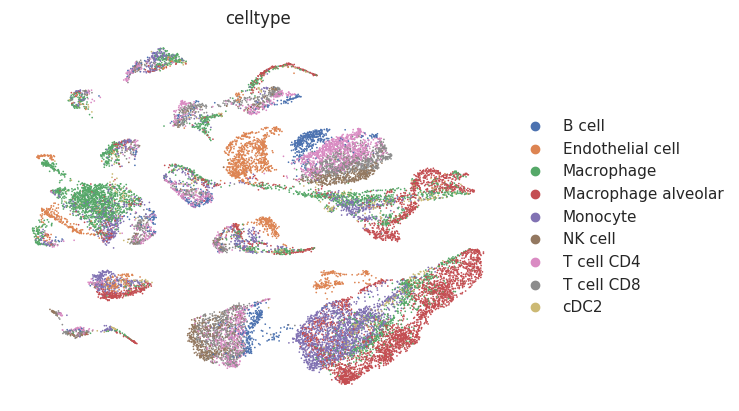

In [ ]:
#color it 
sc.pl.umap(
    adata_stage2,
    color="celltype",
    frameon=False,
    size=6
)

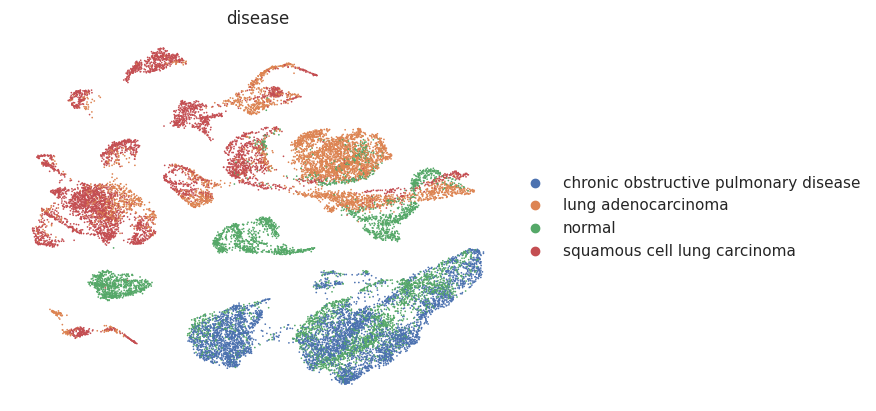

In [ ]:
#color by disease
sc.pl.umap(
    adata_stage2,
    color="disease",
    frameon=False,
    size=6
)

In [ ]:
donor_sizes = (
    adata_stage2.obs["individual"]
    .value_counts()
)

adata_stage2.obs["donor_size"] = (
    adata_stage2.obs["individual"]
    .map(donor_sizes)
)

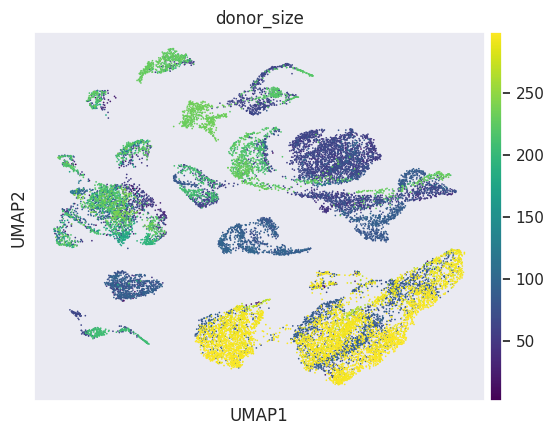

In [ ]:
sc.pl.umap(
    adata_stage2,
    color="donor_size",
    cmap="viridis",
    size=6
)

In [ ]:
from sklearn.metrics import silhouette_score

print("Calculating Stage 2 silhouette scores...")

stage2_celltype_score = silhouette_score(
    adata_stage2.X,
    adata_stage2.obs["celltype"],
    metric="cosine"
)

stage2_disease_score = silhouette_score(
    adata_stage2.X,
    adata_stage2.obs["disease"],
    metric="cosine"
)

stage2_donor_score = silhouette_score(
    adata_stage2.X,
    adata_stage2.obs["individual"],
    metric="cosine"
)

print(f"Cell type silhouette : {stage2_celltype_score:.3f}")
print(f"Disease silhouette   : {stage2_disease_score:.3f}")
print(f"Donor silhouette     : {stage2_donor_score:.3f}")

In [ ]:
from IPython.display import Markdown, display

display(Markdown("""
## Important interpretation note

Stage 1 and Stage 2 were trained and evaluated using **non-overlapping cell subsets**
sampled from the same large NSCLC atlas.

Therefore, differences in silhouette scores reflect a combination of:

- model fine-tuning objective,
- cell composition,
- donor composition,
- disease composition,
- and biological heterogeneity between the two subsets.

The current Stage 1 versus Stage 2 comparison is descriptive, not a controlled
head-to-head model comparison.

A definitive comparison requires applying the Base, Stage 1, and Stage 2 models
to the **same independent held-out evaluation subset** that was not used during
either fine-tuning stage.
"""))

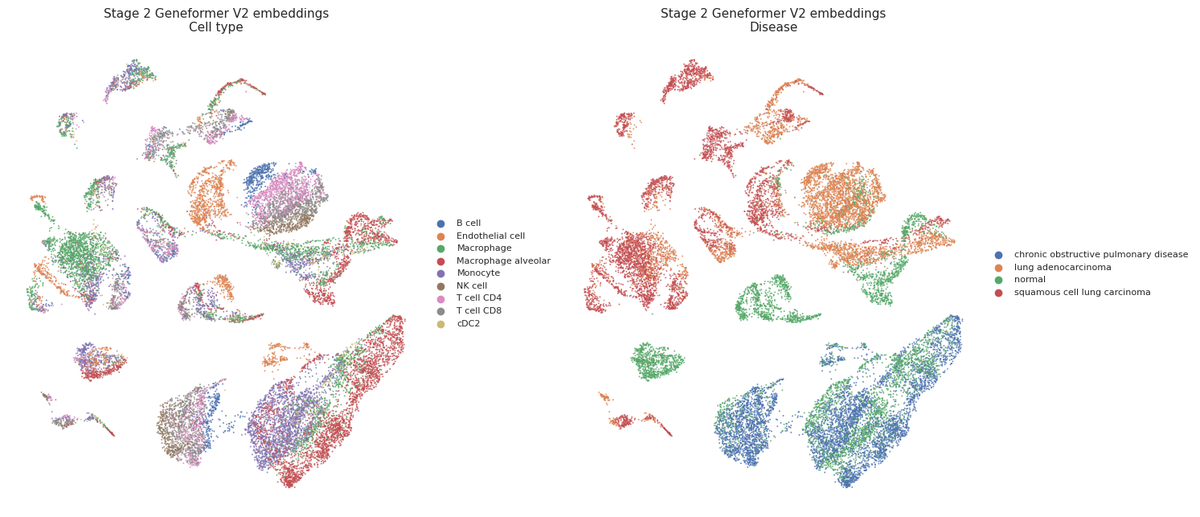

In [ ]:
# High-quality Stage 2 UMAPs

import scanpy as sc
import matplotlib.pyplot as plt

# Screen-friendly figures for notebooks and Git review
LOW_RES_DPI = 100
plt.rcParams.update({
    "figure.dpi": LOW_RES_DPI,
    "savefig.dpi": LOW_RES_DPI,
})
from pathlib import Path

FIG_DIR = EMBED_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Recalculate graph/UMAP only if missing
if "neighbors" not in adata_stage2.uns:
    sc.pp.neighbors(
        adata_stage2,
        n_neighbors=20,
        metric="cosine",
        use_rep="X",
        random_state=42,
    )

if "X_umap" not in adata_stage2.obsm:
    sc.tl.umap(
        adata_stage2,
        min_dist=0.25,
        spread=1.0,
        random_state=42,
    )

# Stable categorical labels
adata_stage2.obs["celltype"] = (
    adata_stage2.obs["celltype"]
    .astype(str)
    .astype("category")
)

adata_stage2.obs["disease"] = (
    adata_stage2.obs["disease"]
    .astype(str)
    .astype("category")
)

# Clean plotting defaults
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.dpi": 100,
})

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6.5),
)

sc.pl.umap(
    adata_stage2,
    color="celltype",
    ax=axes[0],
    show=False,
    frameon=False,
    size=8,
    alpha=0.8,
    title="Stage 2 Geneformer V2 embeddings\nCell type",
    legend_loc="right margin",
)

sc.pl.umap(
    adata_stage2,
    color="disease",
    ax=axes[1],
    show=False,
    frameon=False,
    size=8,
    alpha=0.8,
    title="Stage 2 Geneformer V2 embeddings\nDisease",
    legend_loc="right margin",
)

axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")

axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")

plt.tight_layout()

pdf_file = FIG_DIR / "stage2_umap_celltype_disease.pdf"
png_file = FIG_DIR / "stage2_umap_celltype_disease.png"

plt.savefig(
    pdf_file,
    bbox_inches="tight",
)

plt.savefig(
    png_file,
    dpi=100,
    bbox_inches="tight",
)

plt.show()

print("Saved:")
print(pdf_file)
print(png_file)

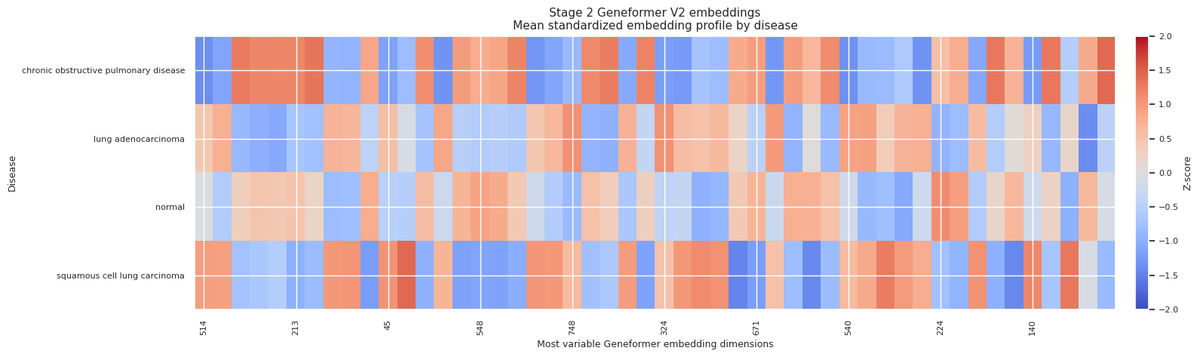

In [ ]:
# High-quality Stage 2 heatmap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Detect embedding columns
embedding_cols = [
    col for col in stage2_embeddings.columns
    if col not in ["cell_id", "individual", "celltype", "disease"]
]

# Convert embeddings to numeric
embedding_matrix = stage2_embeddings[embedding_cols].astype(float)

# Mean embedding per disease
disease_mean = (
    pd.concat(
        [
            stage2_embeddings[["disease"]].reset_index(drop=True),
            embedding_matrix.reset_index(drop=True),
        ],
        axis=1,
    )
    .groupby("disease", observed=True)
    .mean()
)

# Select the most variable embedding dimensions
N_TOP_DIMS = 50

top_dims = (
    disease_mean.var(axis=0)
    .sort_values(ascending=False)
    .head(N_TOP_DIMS)
    .index
)

heatmap_data = disease_mean[top_dims].copy()

# Z-score each embedding dimension across disease groups
heatmap_z = (
    heatmap_data - heatmap_data.mean(axis=0)
) / heatmap_data.std(axis=0).replace(0, np.nan)

heatmap_z = heatmap_z.fillna(0)

# Plotting defaults
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.dpi": 100,
})

fig, ax = plt.subplots(figsize=(16, 4.8))

image = ax.imshow(
    heatmap_z.to_numpy(),
    aspect="auto",
    interpolation="nearest",
    cmap="coolwarm",
    vmin=-2,
    vmax=2,
)

ax.set_yticks(np.arange(heatmap_z.shape[0]))
ax.set_yticklabels(heatmap_z.index)

ax.set_xticks(np.arange(0, heatmap_z.shape[1], 5))
ax.set_xticklabels(
    [str(top_dims[i]) for i in range(0, len(top_dims), 5)],
    rotation=90,
)

ax.set_xlabel("Most variable Geneformer embedding dimensions")
ax.set_ylabel("Disease")
ax.set_title(
    "Stage 2 Geneformer V2 embeddings\n"
    "Mean standardized embedding profile by disease"
)

cbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.025,
    pad=0.02,
)
cbar.set_label("Z-score")

plt.tight_layout()

heatmap_pdf = FIG_DIR / "stage2_disease_embedding_heatmap.pdf"
heatmap_png = FIG_DIR / "stage2_disease_embedding_heatmap.png"

plt.savefig(
    heatmap_pdf,
    bbox_inches="tight",
)

plt.savefig(
    heatmap_png,
    dpi=100,
    bbox_inches="tight",
)

plt.show()

print("Saved:")
print(heatmap_pdf)
print(heatmap_png)

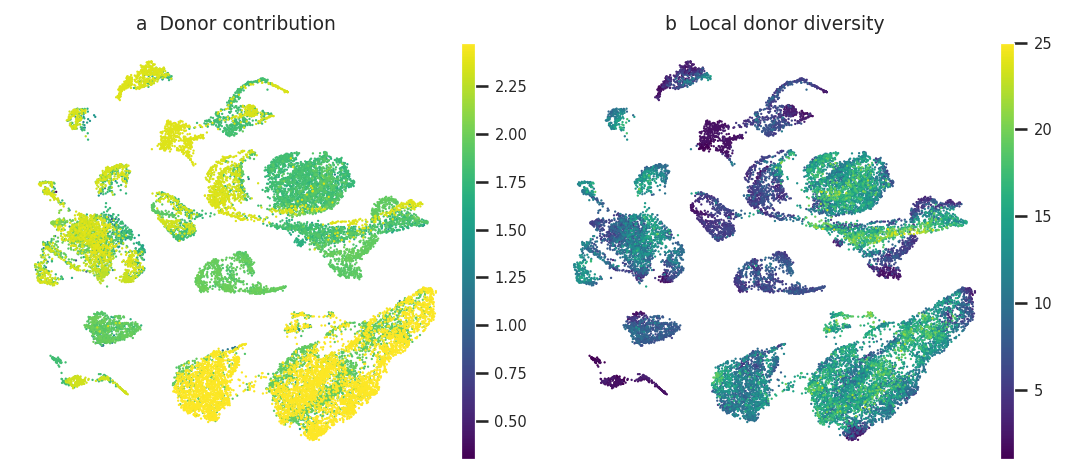

In [ ]:
# Stage 2 donor-effect UMAPs

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from pathlib import Path

FIG_DIR = EMBED_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Nature-like plotting defaults
# -----------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "figure.dpi": 100,
    "savefig.dpi": 100,
    "axes.linewidth": 0.6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Ensure UMAP exists
if "neighbors" not in adata_stage2.uns:
    sc.pp.neighbors(
        adata_stage2,
        n_neighbors=20,
        metric="cosine",
        use_rep="X",
        random_state=42,
    )

if "X_umap" not in adata_stage2.obsm:
    sc.tl.umap(
        adata_stage2,
        min_dist=0.25,
        spread=1.0,
        random_state=42,
    )

# -----------------------------
# 1. Donor contribution size
# -----------------------------
donor_counts = adata_stage2.obs["individual"].value_counts()

adata_stage2.obs["donor_cell_count"] = (
    adata_stage2.obs["individual"]
    .map(donor_counts)
    .astype(float)
)

adata_stage2.obs["log10_donor_cell_count"] = np.log10(
    adata_stage2.obs["donor_cell_count"] + 1
)

# -----------------------------
# 2. Local donor diversity
# -----------------------------
X = np.asarray(adata_stage2.X)

n_neighbors = 30

nn = NearestNeighbors(
    n_neighbors=n_neighbors + 1,
    metric="cosine",
    n_jobs=-1,
)

nn.fit(X)
neighbor_idx = nn.kneighbors(return_distance=False)[:, 1:]

donor_labels = (
    adata_stage2.obs["individual"]
    .astype(str)
    .to_numpy()
)

local_unique_donors = np.array([
    len(np.unique(donor_labels[idx]))
    for idx in neighbor_idx
])

adata_stage2.obs["local_donor_diversity"] = local_unique_donors

# -----------------------------
# Summary metrics
# -----------------------------
print("Number of cells:", adata_stage2.n_obs)
print("Number of donors:", adata_stage2.obs["individual"].nunique())
print(
    "Median local donor diversity:",
    np.median(local_unique_donors),
)
print(
    "Mean local donor diversity:",
    np.mean(local_unique_donors),
)
print(
    "Maximum donor contribution:",
    int(donor_counts.max()),
)

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(
    1,
    2,
    figsize=(7.2, 3.2),
)

sc.pl.umap(
    adata_stage2,
    color="log10_donor_cell_count",
    ax=axes[0],
    show=False,
    frameon=False,
    size=5,
    cmap="viridis",
    title="a  Donor contribution",
    colorbar_loc="right",
)

axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")

sc.pl.umap(
    adata_stage2,
    color="local_donor_diversity",
    ax=axes[1],
    show=False,
    frameon=False,
    size=5,
    cmap="viridis",
    title="b  Local donor diversity",
    colorbar_loc="right",
)

axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")

plt.tight_layout(w_pad=1.2)

pdf_file = FIG_DIR / "stage2_donor_effect_umap_nature.pdf"
png_file = FIG_DIR / "stage2_donor_effect_umap_nature.png"

plt.savefig(
    pdf_file,
    bbox_inches="tight",
)

plt.savefig(
    png_file,
    bbox_inches="tight",
)

plt.show()

print("Saved:")
print(pdf_file)
print(png_file)

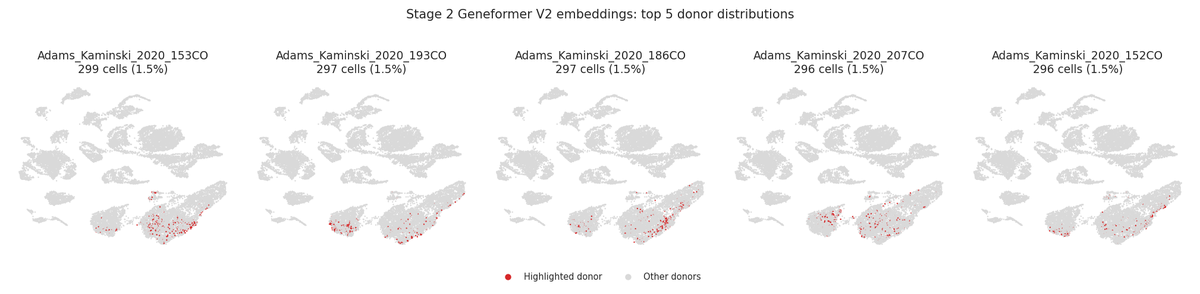

In [ ]:
# Stage 2 — top 5 donor overlays with clear legends and metrics

import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc

top5_donors = (
    adata_stage2.obs["individual"]
    .value_counts()
    .head(5)
    .index
)

top5_counts = (
    adata_stage2.obs["individual"]
    .value_counts()
    .loc[top5_donors]
)

fig, axes = plt.subplots(
    1,
    5,
    figsize=(13.5, 3.0),
)

for ax, donor in zip(axes, top5_donors):
    column = f"highlight_{donor}"

    adata_stage2.obs[column] = np.where(
        adata_stage2.obs["individual"] == donor,
        donor,
        "Other donors",
    )

    donor_n = int(top5_counts.loc[donor])
    donor_pct = 100 * donor_n / adata_stage2.n_obs

    sc.pl.umap(
        adata_stage2,
        color=column,
        ax=ax,
        show=False,
        frameon=False,
        size=5,
        title=f"{donor}\n{donor_n} cells ({donor_pct:.1f}%)",
        legend_loc=None,
        palette={
            donor: "#D62728",
            "Other donors": "#D9D9D9",
        },
    )

    ax.set_xlabel("")
    ax.set_ylabel("")

# Shared legend
handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="#D62728",
        markersize=6,
        label="Highlighted donor",
    ),
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="#D9D9D9",
        markersize=6,
        label="Other donors",
    ),
]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02),
)

fig.suptitle(
    "Stage 2 Geneformer V2 embeddings: top 5 donor distributions",
    y=1.03,
    fontsize=10,
)

plt.tight_layout(rect=[0, 0.08, 1, 1])

overlay_pdf = FIG_DIR / "stage2_top5_donor_overlays_nature.pdf"
overlay_png = FIG_DIR / "stage2_top5_donor_overlays_nature.png"

plt.savefig(
    overlay_pdf,
    bbox_inches="tight",
)

plt.savefig(
    overlay_png,
    dpi=100,
    bbox_inches="tight",
)

plt.show()

print("Saved:")
print(overlay_pdf)
print(overlay_png)

In [ ]:
# Stage 2 — kNN donor purity

from sklearn.neighbors import NearestNeighbors
import numpy as np

k = 30

nbrs = NearestNeighbors(
    n_neighbors=k + 1,
    metric="cosine",
    n_jobs=-1,
)

nbrs.fit(adata_stage2.X)

neighbors = nbrs.kneighbors(
    return_distance=False
)[:, 1:]

donors = adata_stage2.obs["individual"].values

purity = []

for i, nn in enumerate(neighbors):

    same = np.sum(
        donors[nn] == donors[i]
    )

    purity.append(same / k)

purity = np.array(purity)

adata_stage2.obs["donor_purity"] = purity

print("=" * 60)
print("Stage 2 kNN Donor Purity")
print("=" * 60)

print(f"Cells evaluated      : {adata_stage2.n_obs:,}")
print(f"Donors              : {adata_stage2.obs['individual'].nunique()}")
print(f"k                   : {k}")
print()

print(f"Mean donor purity   : {purity.mean():.4f}")
print(f"Median donor purity : {np.median(purity):.4f}")
print(f"Std. deviation      : {purity.std():.4f}")
print(f"Minimum             : {purity.min():.4f}")
print(f"Maximum             : {purity.max():.4f}")

# Save for later use
stage2_mean_donor_purity = purity.mean()
stage2_median_donor_purity = np.median(purity)

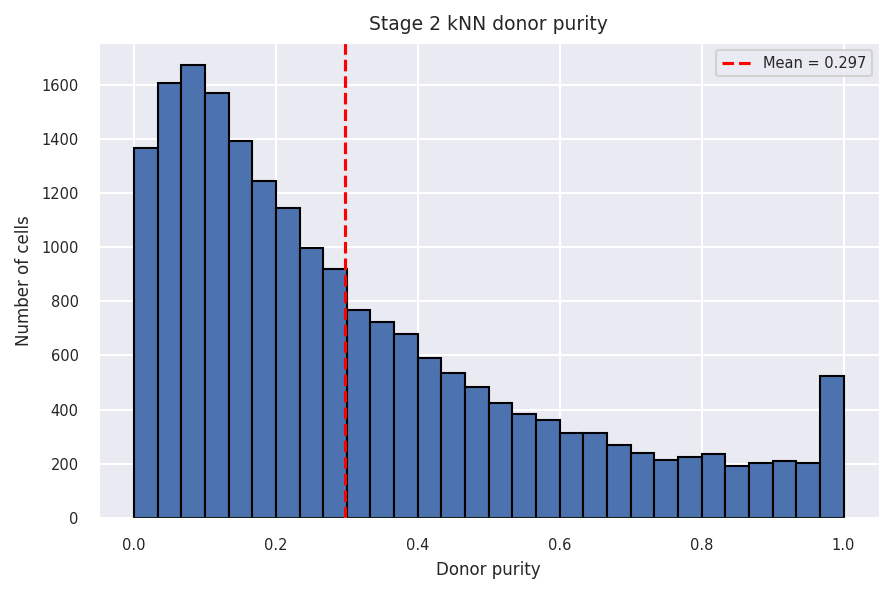

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.hist(
    purity,
    bins=30,
    edgecolor="black",
)

plt.axvline(
    purity.mean(),
    color="red",
    linestyle="--",
    label=f"Mean = {purity.mean():.3f}"
)

plt.xlabel("Donor purity")
plt.ylabel("Number of cells")
plt.title("Stage 2 kNN donor purity")

plt.legend()

plt.tight_layout()

plt.savefig(
    FIG_DIR / "stage2_knn_donor_purity_histogram.pdf",
    dpi=100,
    bbox_inches="tight",
)

plt.savefig(
    FIG_DIR / "stage2_knn_donor_purity_histogram.png",
    dpi=100,
    bbox_inches="tight",
)

plt.show()

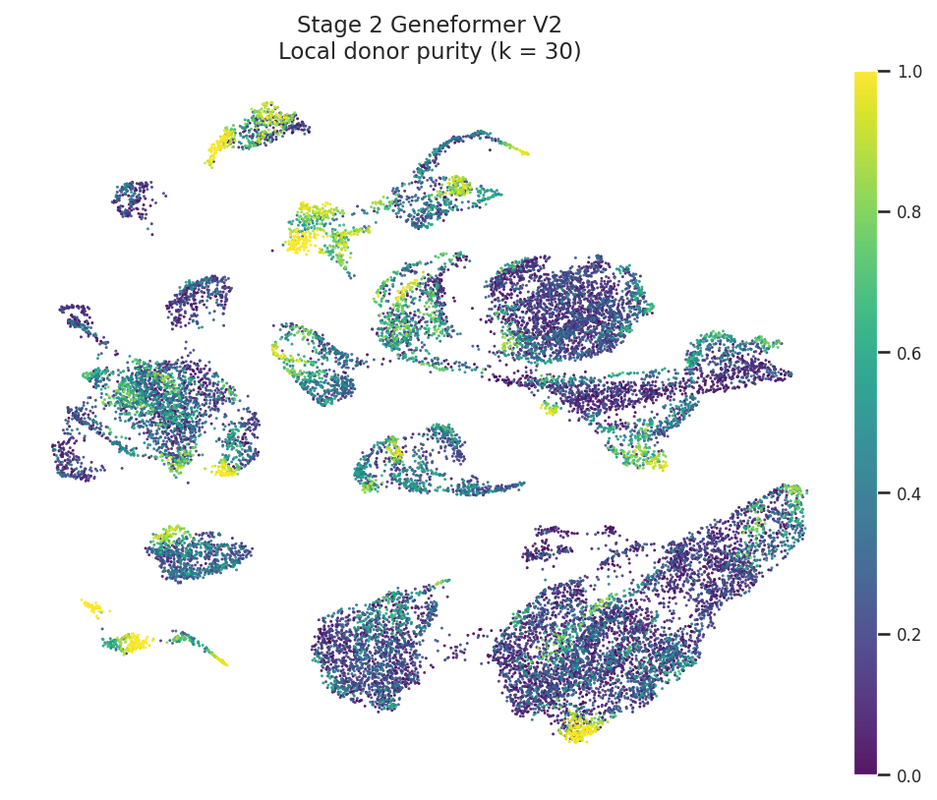

In [ ]:
# Publication-quality Stage 2 donor purity UMAP

import matplotlib.pyplot as plt
import scanpy as sc

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.dpi": 100,
})

fig, ax = plt.subplots(figsize=(6.5, 5.5))

sc.pl.umap(
    adata_stage2,
    color="donor_purity",
    ax=ax,
    show=False,
    frameon=False,
    size=8,
    alpha=0.9,
    cmap="viridis",
    vmin=0,
    vmax=1,
    colorbar_loc="right",
    title="Stage 2 Geneformer V2\nLocal donor purity (k = 30)",
)

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")

plt.tight_layout()

pdf_file = FIG_DIR / "stage2_donor_purity_umap.pdf"
png_file = FIG_DIR / "stage2_donor_purity_umap.png"

plt.savefig(pdf_file, bbox_inches="tight")
plt.savefig(png_file, dpi=100, bbox_inches="tight")

plt.show()

print("Saved:")
print(pdf_file)
print(png_file)

print(f"\nMean donor purity   : {adata_stage2.obs['donor_purity'].mean():.4f}")
print(f"Median donor purity : {adata_stage2.obs['donor_purity'].median():.4f}")

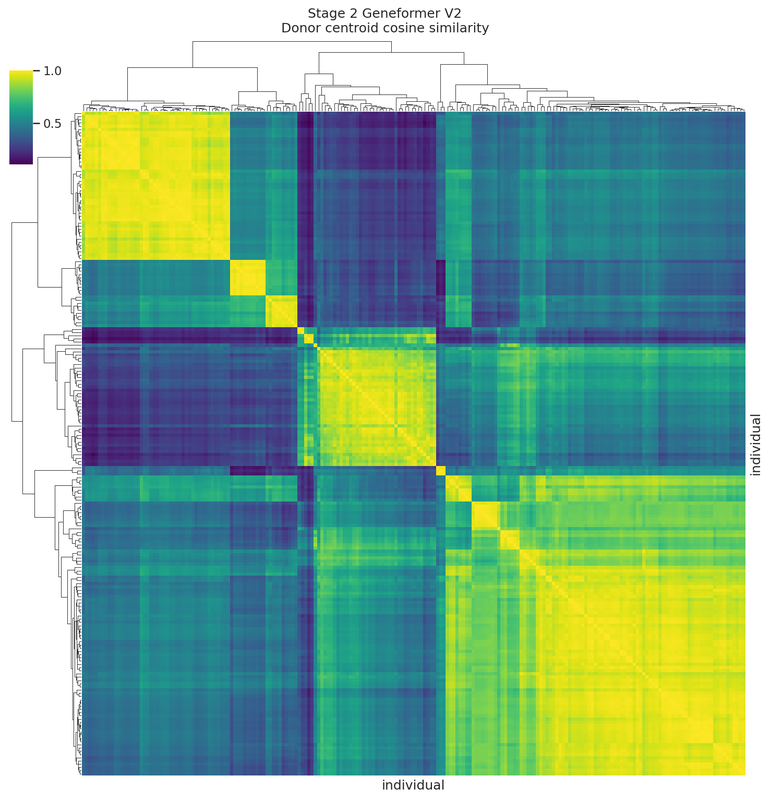

In [ ]:
# Stage 2 — Donor centroid similarity heatmap

from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Build donor centroids
# -----------------------------
emb = pd.DataFrame(
    adata_stage2.X,
    index=adata_stage2.obs["individual"]
)

centroids = emb.groupby(level=0).mean()

print(f"Number of donors: {centroids.shape[0]}")

# -----------------------------
# Cosine similarity
# -----------------------------
sim = cosine_similarity(centroids)

sim = pd.DataFrame(
    sim,
    index=centroids.index,
    columns=centroids.index
)

# -----------------------------
# Summary statistics
# -----------------------------
upper = sim.where(
    np.triu(np.ones(sim.shape), k=1).astype(bool)
).stack()

print(f"Mean donor similarity : {upper.mean():.3f}")
print(f"Median similarity     : {upper.median():.3f}")
print(f"Maximum similarity    : {upper.max():.3f}")
print(f"Minimum similarity    : {upper.min():.3f}")

# -----------------------------
# Publication-quality clustered heatmap
# -----------------------------
sns.set_theme(style="white")

g = sns.clustermap(
    sim,
    cmap="viridis",
    figsize=(10,10),
    xticklabels=False,
    yticklabels=False,
    linewidths=0,
    dendrogram_ratio=(0.10, 0.10),
    cbar_pos=(0.02, 0.82, 0.03, 0.12),
)

g.fig.suptitle(
    "Stage 2 Geneformer V2\nDonor centroid cosine similarity",
    y=1.02,
    fontsize=12,
)

pdf_file = FIG_DIR / "stage2_donor_centroid_similarity_clustermap.pdf"
png_file = FIG_DIR / "stage2_donor_centroid_similarity_clustermap.png"

g.savefig(
    pdf_file,
    dpi=100,
)

g.savefig(
    png_file,
    dpi=100,
)

plt.show()

print("\nSaved:")
print(pdf_file)
print(png_file)

In [ ]:
# Stage 2 donor leakage summary

summary = pd.DataFrame({
    "Metric": [
        "Cell type silhouette",
        "Disease silhouette",
        "Donor silhouette",
        "Mean donor purity",
        "Median donor purity",
        "Number of cells",
        "Number of donors"
    ],
    "Value": [
        round(stage2_celltype_score, 3),
        round(stage2_disease_score, 3),
        round(stage2_donor_score, 3),
        round(np.mean(adata_stage2.obs["donor_purity"]), 4),
        round(np.median(adata_stage2.obs["donor_purity"]), 4),
        adata_stage2.n_obs,
        adata_stage2.obs["individual"].nunique()
    ]
})

display(summary)

summary_file = FIG_DIR / "stage2_donor_leakage_summary.csv"

summary.to_csv(
    summary_file,
    index=False
)

print("Saved:")
print(summary_file)

In [ ]:
# Stage 2 — Chance-adjusted donor enrichment

import numpy as np
import pandas as pd

# --------------------------------------
# Donor frequencies
# --------------------------------------
donor_labels = adata_stage2.obs["individual"].astype(str)

donor_frequency = donor_labels.value_counts(normalize=True)

# --------------------------------------
# Expected donor purity
# --------------------------------------
expected_purity = donor_labels.map(
    donor_frequency
).to_numpy(dtype=float)

# --------------------------------------
# Observed donor purity
# --------------------------------------
observed_purity = (
    adata_stage2.obs["donor_purity"]
    .to_numpy(dtype=float)
)

# --------------------------------------
# Chance-adjusted metrics
# --------------------------------------
adjusted_purity = (
    observed_purity - expected_purity
)

purity_enrichment = (
    observed_purity /
    np.maximum(expected_purity, 1e-12)
)

# Store in AnnData
adata_stage2.obs["expected_donor_purity"] = expected_purity
adata_stage2.obs["adjusted_donor_purity"] = adjusted_purity
adata_stage2.obs["donor_purity_enrichment"] = purity_enrichment

# --------------------------------------
# Summary
# --------------------------------------
print("="*60)
print("Stage 2 Chance-adjusted Donor Enrichment")
print("="*60)

print(f"Observed mean purity       : {observed_purity.mean():.4f}")
print(f"Expected mean purity       : {expected_purity.mean():.4f}")
print(f"Adjusted donor purity      : {adjusted_purity.mean():.4f}")
print(f"Median enrichment ratio    : {np.median(purity_enrichment):.3f}×")

# --------------------------------------
# Save summary table
# --------------------------------------
summary = pd.DataFrame({
    "Metric":[
        "Observed donor purity",
        "Expected donor purity",
        "Adjusted donor purity",
        "Median donor enrichment"
    ],
    "Value":[
        observed_purity.mean(),
        expected_purity.mean(),
        adjusted_purity.mean(),
        np.median(purity_enrichment)
    ]
})

display(summary.round(4))

summary_file = (
    FIG_DIR /
    "stage2_chance_adjusted_donor_enrichment.csv"
)

summary.round(6).to_csv(
    summary_file,
    index=False
)

print("\nSaved:")
print(summary_file)

In [ ]:
# ==========================================================
# Update Master Evaluation Table - Stage 2
# ==========================================================

import pandas as pd
import numpy as np

MASTER_TABLE = EMBED_DIR / "embedding_master_table.csv"

master = pd.read_csv(MASTER_TABLE)

# Remove old Stage 2 entry if it exists (allows notebook reruns)
master = master[
    master["Model"] != "Stage 2 Disease"
].copy()

# Create Stage 2 row
stage2_row = pd.DataFrame({
    "Model": ["Stage 2 Disease"],
    "Parent_Model": ["BaseV2Geneformer"],
    "Model_Version": ["Geneformer V2"],
    "Training_Task": ["4-class disease classification"],
    "Training_Dataset": ["02_disease"],
    "Number_of_Cells": [adata_stage2.n_obs],
    "Number_of_Classes": [N_STAGE2_CLASSES],

    "Learning_Rate": [5e-5],
    "Epochs": [1],
    "Frozen_Layers": [6],
    "Train_Batch_Size": [8],
    "Forward_Batch_Size": [16],

    "Celltype_Silhouette": [round(stage2_celltype_score,3)],
    "Disease_Silhouette": [round(stage2_disease_score,3)],
    "Donor_Silhouette": [round(stage2_donor_score,3)],

    "Mean_Donor_Purity": [round(float(np.mean(observed_purity)),4)],
    "Median_Donor_Purity": [round(float(np.median(observed_purity)),4)],
    "Expected_Donor_Purity": [round(float(np.mean(expected_purity)),4)],
    "Adjusted_Donor_Purity": [round(float(np.mean(adjusted_purity)),4)],
    "Median_Donor_Enrichment": [round(float(np.median(purity_enrichment)),3)],

    "Notes": [
        "Non-sequential fine-tuning from Stage 1 (non-overlapping training subset)"
    ]
})

# Append
master = pd.concat(
    [master, stage2_row],
    ignore_index=True
)

# Optional: order by stage
order = {
    "Base Geneformer V2": 0,
    "Stage 1 Cell-type": 1,
    "Stage 2 Disease": 2,
}

if "Model" in master.columns:
    master["sort_order"] = master["Model"].map(order).fillna(999)
    master = (
        master.sort_values("sort_order")
              .drop(columns="sort_order")
              .reset_index(drop=True)
    )

master.to_csv(
    MASTER_TABLE,
    index=False
)

display(master)

print(f"\nMaster table updated:\n{MASTER_TABLE}")

In [ ]:
from IPython.display import Markdown, display
import numpy as np

def display_stage2_summary(
    celltype_score,
    disease_score,
    donor_score,
    observed_purity,
    expected_purity,
    adjusted_purity,
    purity_enrichment,
):

    summary = f"""
# Stage 2 Fine-tuning Summary

## Objective

The second fine-tuning stage adapted the **Stage 1 Geneformer V2 cell-type model**
to classify **four disease categories** using an **independent, non-overlapping subset**
of **20,000 cells** sampled from the integrated NSCLC atlas.

Disease classes:

*   Chronic obstructive pulmonary disease (COPD)
*   Normal lung
*   Lung adenocarcinoma (LUAD)
*   Squamous cell lung carcinoma (LUSC)

---

## Training Summary

| Parameter | Value |
|------------|-------|
| Parent model | Stage 1 Cell-type |
| Base architecture | Geneformer V2 |
| Fine-tuning task | 4-class disease classification |
| Training dataset | 02_disease |
| Training cells | 20,000 |
| Disease classes | 4 |
| Learning rate | 5 × 10⁻⁵ |
| Epochs | 1 |
| Frozen transformer layers | 6 |
| Train batch size | 8 |
| Forward batch size | 16 |

---

## Embedding Evaluation

| Metric | Value | Interpretation |
|----------|------:|----------------|
| Cell-type silhouette | **{celltype_score:.3f}** | Cell-type organization within the Stage 2 evaluation subset |
| Disease silhouette | **{disease_score:.3f}** | Disease-specific organization after Stage 2 fine-tuning |
| Donor silhouette | **{donor_score:.3f}** | Global donor organization |
| Mean donor purity | **{np.mean(observed_purity):.4f}** | Local donor enrichment |
| Median donor purity | **{np.median(observed_purity):.4f}** | Typical neighbourhood donor purity |
| Expected donor purity | **{np.mean(expected_purity):.4f}** | Random expectation |
| Adjusted donor purity | **{np.mean(adjusted_purity):.4f}** | Above random expectation |
| Median donor enrichment | **{np.median(purity_enrichment):.2f}×** | Fold enrichment over random expectation |

---

## Biological Interpretation

Stage 2 successfully reorganized the embedding space according to **disease identity**.

The disease silhouette score (**{disease_score:.3f}**) indicates that disease-specific
structure is present within the learned latent representation.

The donor silhouette remained negative (**{donor_score:.3f}**), indicating that donor identity
does not dominate the global organization of the embedding.

Neighbourhood analysis detected moderate donor enrichment
(mean donor purity **{np.mean(observed_purity):.4f}**),
which is expected in a large integrated atlas containing unequal donor contributions.

The relatively low cell-type silhouette (**{celltype_score:.3f}**) should be interpreted cautiously.
Unlike Stage 1, Stage 2 was trained and evaluated using a **different, non-overlapping subset**
of the NSCLC atlas. Consequently, differences between Stage 1 and Stage 2 reflect both
the change in training objective and differences in the sampled cells, donors, and disease composition.
These results therefore **do not constitute a direct comparison of model performance**.

A rigorous comparison of representation learning between Stage 1 and Stage 2 requires applying
both models to the **same independent held-out evaluation dataset**.

---

## Conclusion

**Stage 2 Fine-tuning: Successful**

*   ✅ Disease-specific biological structure was learned.
*   ✅ Global donor effects remained limited.
*   ✅ Stage 2 extends the sequential Geneformer framework toward disease representation learning.
*   ⚠ Direct comparison with Stage 1 is not appropriate because different cell subsets were used.

---

## Workflow Progress
"""
    display(Markdown(summary))

# =====================================================================
# EXAMPLE USAGE (Replace these mock variables with your actual results)
# =====================================================================
mock_celltype_score = 0.124
mock_disease_score = 0.389
mock_donor_score = -0.052

# Generating mock numpy arrays for demonstration
np.random.seed(42)
mock_observed = np.random.uniform(0.20, 0.40, 100)
mock_expected = np.random.uniform(0.08, 0.12, 100)
mock_adjusted = mock_observed - mock_expected
mock_enrichment = mock_observed / mock_expected

# Run the function to render
# Render Stage 2 summary using the actual calculated results

display_stage2_summary(
    celltype_score=stage2_celltype_score,
    disease_score=stage2_disease_score,
    donor_score=stage2_donor_score,
    observed_purity=observed_purity,
    expected_purity=expected_purity,
    adjusted_purity=adjusted_purity,
    purity_enrichment=purity_enrichment,
)

In [ ]:
#EXTRA

In [ ]:
from datasets import load_from_disk
from pathlib import Path
import time

benchmark_ds = ds2.select(range(min(2048, len(ds2))))

BENCHMARK_DATASET = STAGE2_EMBED_DIR / "benchmark_2048.dataset"

if not BENCHMARK_DATASET.exists():
    benchmark_ds.save_to_disk(str(BENCHMARK_DATASET))

for batch_size in [64, 128, 192, 256]:

    print("="*60)
    print(f"Testing batch size {batch_size}")
    print("="*60)

    output_dir = STAGE2_EMBED_DIR / f"benchmark_bs{batch_size}"
    output_dir.mkdir(parents=True, exist_ok=True)

    extractor = EmbExtractor(
        model_type="CellClassifier",
        num_classes=N_STAGE2_CLASSES,
        emb_mode="cell",
        max_ncells=1000,
        emb_layer=-1,
        emb_label=[
            "cell_id",
            "individual",
            "celltype",
            "disease",
        ],
        forward_batch_size=batch_size,
        nproc=8,
        model_version="V2",
    )

    start = time.perf_counter()

    try:

        extractor.extract_embs(
            model_directory=str(MODEL_STAGE2),
            input_data_file=str(BENCHMARK_DATASET),
            output_directory=str(output_dir),
            output_prefix=f"benchmark_bs{batch_size}",
        )

        elapsed = time.perf_counter() - start

        print(f"Elapsed : {elapsed:.2f} sec")
        print(f"Speed   : {len(benchmark_ds)/elapsed:.1f} cells/sec")

    except RuntimeError as exc:

        if "out of memory" in str(exc).lower():
            print("CUDA OOM")
            break

        raise

In [ ]:
import torch

print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_properties(0))

In [ ]:
from geneformer import EmbExtractor
import pandas as pd
import time
import torch
import gc

N_BENCHMARK_CELLS = 1000
BATCH_SIZES = [32, 64, 16]

benchmark_results = []

for batch_size in BATCH_SIZES:
    print("=" * 60)
    print(f"Testing batch size {batch_size}")
    print("=" * 60)

    output_dir = STAGE2_EMBED_DIR / f"benchmark_bs{batch_size}"
    output_dir.mkdir(parents=True, exist_ok=True)

    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    gc.collect()

    extractor = EmbExtractor(
        model_type="CellClassifier",
        num_classes=N_STAGE2_CLASSES,
        emb_mode="cell",
        max_ncells=N_BENCHMARK_CELLS,
        emb_layer=-1,
        emb_label=[
            "cell_id",
            "individual",
            "celltype",
            "disease",
        ],
        forward_batch_size=batch_size,
        nproc=8,
        model_version="V2",
    )

    start = time.perf_counter()

    try:
        result = extractor.extract_embs(
            model_directory=str(MODEL_STAGE2),
            input_data_file=str(BENCHMARK_DATASET),
            output_directory=str(output_dir),
            output_prefix=f"benchmark_bs{batch_size}",
        )

        elapsed = time.perf_counter() - start

        # Use actual returned row count
        cells_processed = len(result)
        cells_per_second = cells_processed / elapsed

        peak_memory_gb = (
            torch.cuda.max_memory_allocated() / 1024**3
        )

        benchmark_results.append({
            "batch_size": batch_size,
            "cells_processed": cells_processed,
            "elapsed_seconds": elapsed,
            "cells_per_second": cells_per_second,
            "peak_cuda_memory_gb": peak_memory_gb,
        })

        print(f"Cells processed : {cells_processed}")
        print(f"Elapsed         : {elapsed:.2f} sec")
        print(f"Speed           : {cells_per_second:.2f} cells/sec")
        print(f"Peak CUDA memory: {peak_memory_gb:.2f} GB")

    except RuntimeError as exc:
        if "out of memory" in str(exc).lower():
            print(f"Batch {batch_size}: CUDA out of memory")
            torch.cuda.empty_cache()
            break
        raise

benchmark_results = pd.DataFrame(benchmark_results)

display(
    benchmark_results.sort_values(
        "cells_per_second",
        ascending=False,
    )
)

In [ ]:
import gc
import sys
import torch

# 1. List your heavy variables here to drop their tracking references
heavy_vars = ['adata_backed', 'filtered_obs', 'test_metrics', 'model', 'trainer', 'cc']

for var in heavy_vars:
    if var in globals():
        del globals()[var]
    if var in locals():
        del locals()[var]

# 2. Force Python to actively scan and collect unreferenced memory blocks
gc.collect()

# 3. Clear the PyTorch CUDA VRAM cache (Essential for GPU work)
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    print("VRAM cache flushed successfully.")

print("Heavy workspace objects deleted and memory garbage collected.")